In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install tensorflow
!pip install matplotlib


In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.move("/content/kaggle (1).json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)


In [ ]:
!kaggle datasets download -d gpiosenka/butterfly-images40-species


Dataset URL: https://www.kaggle.com/datasets/gpiosenka/butterfly-images40-species
License(s): CC0-1.0
butterfly-images40-species.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -q butterfly-images40-species.zip -d butterflies_dataset

replace butterflies_dataset/EfficientNetB0-100-(224 X 224)- 97.59.h5? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os

data_dir = "butterflies_dataset"
for root, dirs, files in os.walk(data_dir):
    print(f"📁 {root} - {len(files)} files")
    if len(dirs) > 0:
        print(f"   └─ Subfolders: {dirs}")
    break


📁 butterflies_dataset - 3 files
   └─ Subfolders: ['valid', 'test', 'train']


In [ ]:
import os

train_dir = os.path.join(data_dir, "train")
species = sorted(os.listdir(train_dir))
print(f"Total species: {len(species)}\n")
print("Sample species folders:")
print(species[:10])


Total species: 100

Sample species folders:
['ADONIS', 'AFRICAN GIANT SWALLOWTAIL', 'AMERICAN SNOOT', 'AN 88', 'APPOLLO', 'ARCIGERA FLOWER MOTH', 'ATALA', 'ATLAS MOTH', 'BANDED ORANGE HELICONIAN', 'BANDED PEACOCK']


In [ ]:
moth_keywords = ['moth']
species_map = {}

for name in species:
    label = 'moth' if any(word in name.lower() for word in moth_keywords) else 'butterfly'
    species_map[name] = label

from collections import Counter
print(Counter(species_map.values()))


Counter({'butterfly': 80, 'moth': 20})


In [ ]:
import shutil

binary_data_dir = "butterflies_moths_dataset"
os.makedirs(os.path.join(binary_data_dir, 'butterfly'), exist_ok=True)
os.makedirs(os.path.join(binary_data_dir, 'moth'), exist_ok=True)

def organize_images(source_dir, binary_dir, species_map):
    for species_name in os.listdir(source_dir):
        species_folder = os.path.join(source_dir, species_name)
        if os.path.isdir(species_folder):

            label = species_map.get(species_name, None)
            if label:
                label_folder = os.path.join(binary_dir, label)
                for img_name in os.listdir(species_folder):
                    img_path = os.path.join(species_folder, img_name)

                    shutil.move(img_path, os.path.join(label_folder, img_name))

organize_images(os.path.join(train_dir), binary_data_dir, species_map)

print("Images have been reorganized.")


Images have been reorganized.


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define source and target directories
binary_data_dir = "butterflies_moths_dataset"
source_butterfly_dir = os.path.join(binary_data_dir, 'butterfly')
source_moth_dir = os.path.join(binary_data_dir, 'moth')

# Define final dataset folders
binary_train_dir = os.path.join(binary_data_dir, 'train')
binary_valid_dir = os.path.join(binary_data_dir, 'valid')
binary_test_dir = os.path.join(binary_data_dir, 'test')

# Create directory structure
for split_dir in [binary_train_dir, binary_valid_dir, binary_test_dir]:
    os.makedirs(os.path.join(split_dir, 'butterfly'), exist_ok=True)
    os.makedirs(os.path.join(split_dir, 'moth'), exist_ok=True)

def split_and_move_images(source_dir, label, train_dir, valid_dir, test_dir, valid_size=0.1, test_size=0.1):
    images = os.listdir(source_dir)
    train_imgs, temp_imgs = train_test_split(images, test_size=valid_size + test_size, random_state=42)
    valid_imgs, test_imgs = train_test_split(temp_imgs, test_size=test_size / (valid_size + test_size), random_state=42)

    for img_list, target_dir in zip([train_imgs, valid_imgs, test_imgs], [train_dir, valid_dir, test_dir]):
        for img in img_list:
            src_path = os.path.join(source_dir, img)
            dest_path = os.path.join(target_dir, label, img)
            shutil.move(src_path, dest_path)

# Split and move butterfly images
split_and_move_images(source_butterfly_dir, 'butterfly', binary_train_dir, binary_valid_dir, binary_test_dir)

# Split and move moth images
split_and_move_images(source_moth_dir, 'moth', binary_train_dir, binary_valid_dir, binary_test_dir)

print("✅ Images successfully split into train, valid, and test folders.")


✅ Images successfully split into train, valid, and test folders.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
binary_data_dir = 'butterflies_moths_dataset'


train_data_dir = os.path.join(binary_data_dir, 'train')
valid_data_dir = os.path.join(binary_data_dir, 'valid')
test_data_dir = os.path.join(binary_data_dir, 'test')

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=30, width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_data_dir, target_size=(150, 150), batch_size=32, class_mode='binary')
valid_generator = valid_datagen.flow_from_directory(valid_data_dir, target_size=(150, 150), batch_size=32, class_mode='binary')
test_generator = test_datagen.flow_from_directory(test_data_dir, target_size=(150, 150), batch_size=32, class_mode='binary')

print(f"Train images: {train_generator.samples}")
print(f"Validation images: {valid_generator.samples}")
print(f"Test images: {test_generator.samples}")


Found 263 images belonging to 2 classes.
Found 33 images belonging to 2 classes.
Found 34 images belonging to 2 classes.
Train images: 263
Validation images: 33
Test images: 34


In [ ]:
# CNN
from tensorflow import keras
import tensorflow.keras as keras
from tensorflow.keras import layers, models


model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=15,
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // valid_generator.batch_size
)

model.save('butterfly_moth_classifier.h5')


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4723 - loss: 1.5861 - val_accuracy: 0.5625 - val_loss: 0.6756
Epoch 2/15
1/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4688 - loss: 0.7310

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.4688 - loss: 0.7310 - val_accuracy: 0.5625 - val_loss: 0.6513
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6114 - loss: 0.6234 - val_accuracy: 0.7188 - val_loss: 0.5480
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 380ms/step - accuracy: 0.7188 - loss: 0.5718 - val_accuracy: 0.6875 - val_loss: 0.5457
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6577 - loss: 0.5400 - val_accuracy: 0.7500 - val_loss: 0.4976
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.7812 - loss: 0.4788 - val_accuracy: 0.7500 - val_loss: 0.4870
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7886 - loss: 0.4579 - val_accuracy: 0.8125 - val_loss: 0.4302
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - accuracy: 0.8750 - loss: 0.3299 - val_accuracy: 0.8125 - val_loss: 0.4369
Epoch 9/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.8062 - loss: 0.3813 - val_accuracy: 0.8438 - val_loss: 0.3336
Epoch 10/15

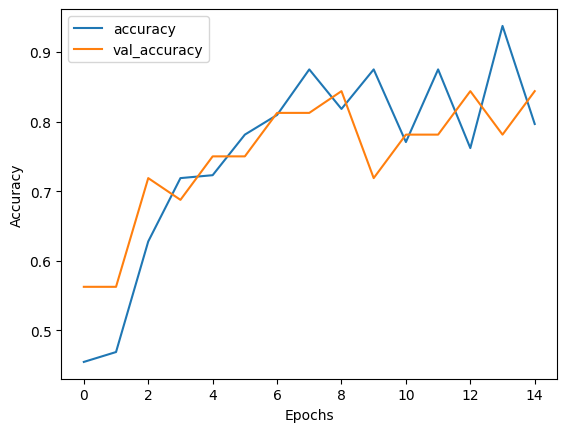

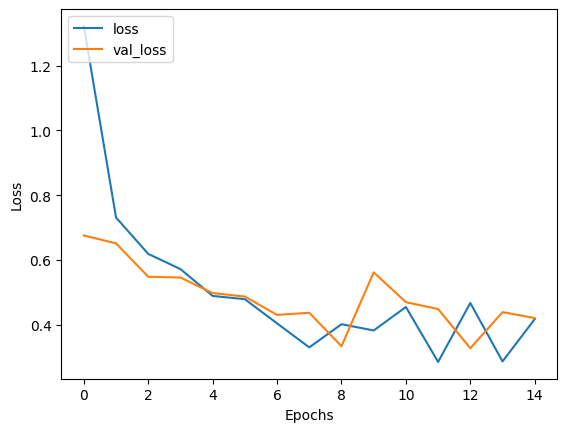

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.show()

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper left')
plt.show()


In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test accuracy: {test_acc*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.8438 - loss: 0.2619
Test accuracy: 84.38%


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving R.jpg to R.jpg


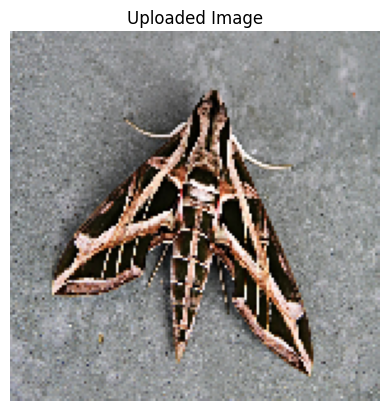

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Replace 'your_image.jpg' with the actual file name you uploaded
img_path = list(uploaded.keys())[0]

# Load and preprocess the image
img = image.load_img(img_path, target_size=(150, 150))  # Resize to model's expected input
img_array = image.img_to_array(img) / 255.0              # Normalize to [0, 1]
img_array = np.expand_dims(img_array, axis=0)            # Add batch dimension

# Display the image
plt.imshow(img)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()


In [ ]:
# Predict the class (0 or 1)
prediction = model.predict(img_array)[0][0]

# Interpret the result
if prediction < 0.5:
    print("Predicted class: MOTH")
else:
    print("Predicted class: BUTTERFLY")

print(f"Raw model output (sigmoid probability): {prediction:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted class: MOTH
Raw model output (sigmoid probability): 0.0313


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving OIP.jpg to OIP.jpg


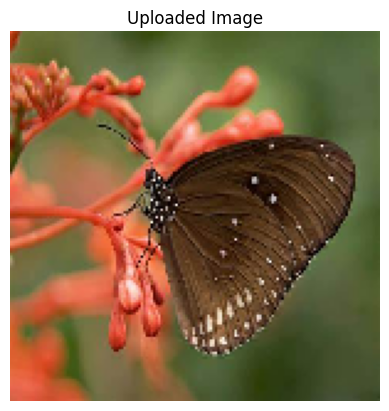

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Replace 'your_image.jpg' with the actual file name you uploaded
img_path = list(uploaded.keys())[0]

# Load and preprocess the image
img = image.load_img(img_path, target_size=(150, 150))  # Resize to model's expected input
img_array = image.img_to_array(img) / 255.0              # Normalize to [0, 1]
img_array = np.expand_dims(img_array, axis=0)            # Add batch dimension

# Display the image
plt.imshow(img)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

In [ ]:
# Predict the class (0 or 1)
prediction = model.predict(img_array)[0][0]

# Interpret the result
if prediction < 0.5:
    print("Predicted class: MOTH")
else:
    print("Predicted class: BUTTERFLY")

print(f"Raw model output (sigmoid probability): {prediction:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted class: BUTTERFLY
Raw model output (sigmoid probability): 0.9575
